# wyrm2 local models vs the frontier — measured + eval comparison

Two kinds of data, kept clearly separate:

- **Measured here** (`local`): tokens/s, context we can actually run, VRAM —
  from the E1–E5 runs on 2×RTX 5090 (`cluster/docs/inference/runs/`).
- **Third-party evals** (`ext`): SWE-bench Verified, GPQA, AIME, LiveCodeBench —
  pulled from vendor cards and independent leaderboards (July 2026). Every number
  carries a source URL in `SOURCES` below.

**Big caveat on eval comparability.** SWE-bench Verified numbers mix vendor
self-reports (which vary by agent scaffold, e.g. OpenHands N-turns) with
independent leaderboards (vals.ai). They are **not** strictly comparable — treat
±several points as noise, and read the trend, not the decimal. Anchor numbers for
the very newest closed models had conflicting web reports; the shakier ones are
omitted or flagged rather than guessed.

In [1]:
from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})

# --- source URLs (reproducible links) -----------------------------------------
SOURCES = {
    "qwen3coder": "https://huggingface.co/Qwen/Qwen3-Coder-30B-A3B-Instruct",
    "gptoss": "https://arxiv.org/abs/2508.10925",  # OpenAI gpt-oss model card
    "qwen35": "https://huggingface.co/Qwen/Qwen3.5-35B-A3B",
    "devstral": "https://mistral.ai/news/devstral-2-vibe-cli/",
    "valsai_swe": "https://www.vals.ai/benchmarks/swebench",  # independent, dated 2026-07-17
    "gpt5": "https://openai.com/index/introducing-gpt-5/",
    "sonnet45": "https://www.anthropic.com/news/claude-sonnet-4-5",
    "runs": "cluster/docs/inference/runs/  (E1–E5, measured on 2×5090)",
}

In [2]:
# --- MEASURED on 2×5090 (local) ------------------------------------------------
@dataclass
class Measured:
    label: str
    runtime: str
    # decode tokens/s at input context (K tokens) -> tok/s
    decode: dict = field(default_factory=dict)
    allocated_ctx_k: float = 0.0  # largest context that loads + completes (K tokens)
    vram_gb: float = 0.0  # peak, per GPU (max of the two)
    tools: str = ""  # tool-calling smoke result
    note: str = ""


MEASURED = [
    Measured("Qwen3-Coder-30B", "vLLM TP2 AWQ", {8: 271, 32: 235, 128: 199}, 262, 30.7, "single+parallel+multi ✓"),
    Measured("gpt-oss-20b (vLLM)", "vLLM TP1 MXFP4", {8: 1356, 32: 1035, 128: 1494}, 128, 15.0, "parallel ✗ (model)"),
    Measured("gpt-oss-20b (Ollama)", "Ollama GGUF", {8: 1154, 32: 917, 128: 636}, 128, 15.0, "parallel ✗ (model)"),
    Measured("Qwen3.5-35B-A3B", "vLLM TP2 FP8 (GDN)", {8: 231, 32: 226, 128: 211}, 262, 29.0, "✗ hermes parser"),
    Measured("Devstral-24B", "vLLM TP2 FP8 dense", {8: 96, 32: 89}, 128, 30.7, "single+parallel+multi ✓"),
    Measured("Qwen2.5-7B-1M", "vLLM TP2", {}, 0, 0.0, note="1M blocked: DCA has no sm_120 kernel"),
]

# --- THIRD-PARTY EVALS (ext) ---------------------------------------------------
# SWE-bench Verified — the one eval with coverage across all our models + anchors.
# (score, source_key, kind)  kind: "local" = we can run it; "anchor" = closed frontier ref
SWEBENCH = {
    "Qwen3-Coder-30B": (51.9, "qwen3coder", "local"),
    "gpt-oss-20b": (60.7, "gptoss", "local"),  # high reasoning effort
    "Devstral-24B": (68.0, "devstral", "local"),
    "Qwen3.5-35B-A3B": (69.2, "qwen35", "local"),
    "Claude Sonnet 4.5": (77.2, "sonnet45", "anchor"),  # 82.0 w/ parallel compute
    "Gemini 3.5 Flash": (78.8, "valsai_swe", "anchor"),
    "GPT-5.5": (82.6, "valsai_swe", "anchor"),
    "Claude Opus 4.8": (88.6, "valsai_swe", "anchor"),
    "Claude Fable 5": (95.0, "valsai_swe", "anchor"),
}

# Reasoning-eval coverage (only models that report them; coding specialists mostly don't).
# metric -> {model: value}
REASONING = {
    "GPQA Diamond": {
        "gpt-oss-20b": 71.5,
        "Qwen3.5-35B-A3B": 84.2,
        "Claude Sonnet 4.5": 83.4,
        "GPT-5": 88.4,
    },
    "AIME 2025": {  # gpt-oss & GPT-5/Sonnet without-tools where noted
        "gpt-oss-20b": 98.7,  # with tools
        "Qwen3.5-35B-A3B": 93.3,  # AIME'26 (card doesn't split; treat as recent-AIME)
        "Claude Sonnet 4.5": 87.0,  # without tools
        "GPT-5": 94.6,  # without tools
    },
    "LiveCodeBench": {  # v6 for Qwen3.5; others report varying versions — sparse
        "Qwen3.5-35B-A3B": 74.6,
    },
}

LOCAL_COLOR, ANCHOR_COLOR = "#2a7fff", "#c0392b"

## 1. Decode throughput we can actually get (measured)

Tokens/s tracks **active parameters**: the small-active MoEs fly, the dense 24B
crawls. Ollama vs vLLM shown for gpt-oss (runtime matters, esp. at long context).

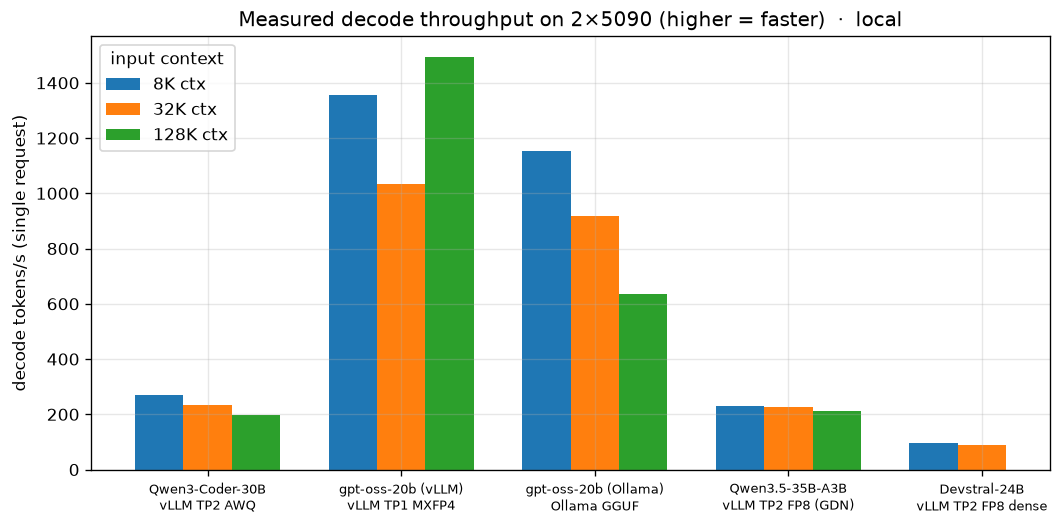

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
runnable = [m for m in MEASURED if m.decode]
ctxs = [8, 32, 128]
x = np.arange(len(runnable))
w = 0.25
for i, c in enumerate(ctxs):
    vals = [m.decode.get(c, np.nan) for m in runnable]
    ax.bar(x + (i - 1) * w, vals, w, label=f"{c}K ctx")
ax.set_xticks(x)
ax.set_xticklabels([f"{m.label}\n{m.runtime}" for m in runnable], fontsize=8)
ax.set_ylabel("decode tokens/s (single request)")
ax.set_title("Measured decode throughput on 2×5090 (higher = faster)  ·  local")
ax.legend(title="input context")
fig.tight_layout()
fig.savefig("fig1_decode_tps.png", bbox_inches="tight")

## 2. Context window we can run (measured allocated context)

Practical ceiling today is ~256K. The 1M attempt is **blocked by kernels, not
memory** (dual-chunk attention has no Blackwell/sm_120 build in vLLM 0.25.1).

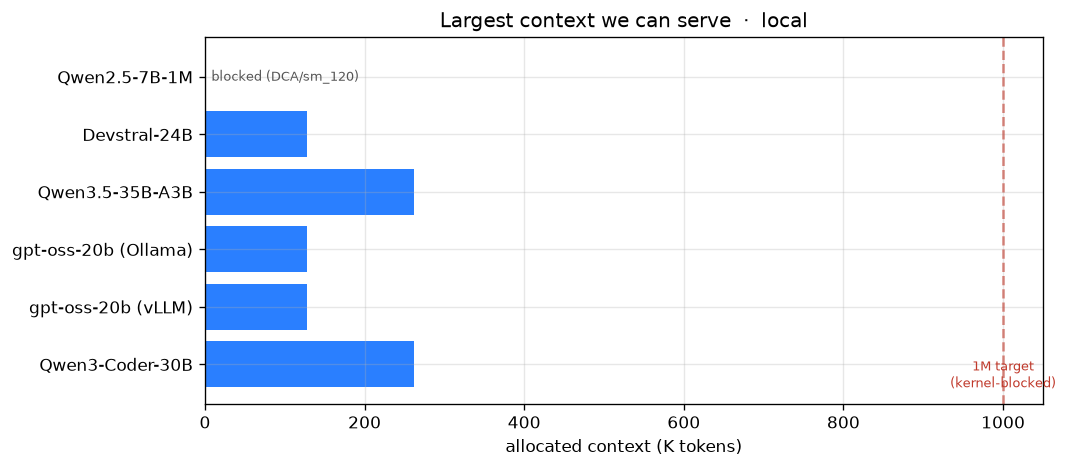

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
cm = [m for m in MEASURED]
ctx_vals = [m.allocated_ctx_k for m in cm]
colors = ["#888" if v == 0 else LOCAL_COLOR for v in ctx_vals]
bars = ax.barh([m.label for m in cm], ctx_vals, color=colors)
ax.set_xlabel("allocated context (K tokens)")
ax.set_title("Largest context we can serve  ·  local")
ax.axvline(1000, ls="--", color="#c0392b", alpha=0.6)
ax.text(1000, -0.4, "1M target\n(kernel-blocked)", color="#c0392b", fontsize=8, ha="center")
for m, b in zip(cm, bars):
    if m.allocated_ctx_k == 0:
        ax.text(8, b.get_y() + b.get_height() / 2, "blocked (DCA/sm_120)", va="center", fontsize=8, color="#555")
fig.tight_layout()
fig.savefig("fig2_context.png", bbox_inches="tight")

## 3. SWE-bench Verified — local models vs the frontier

The one eval everyone reports. Blue = we can run it locally; red = closed
frontier reference. Mind the comparability caveat (self-report vs leaderboard).

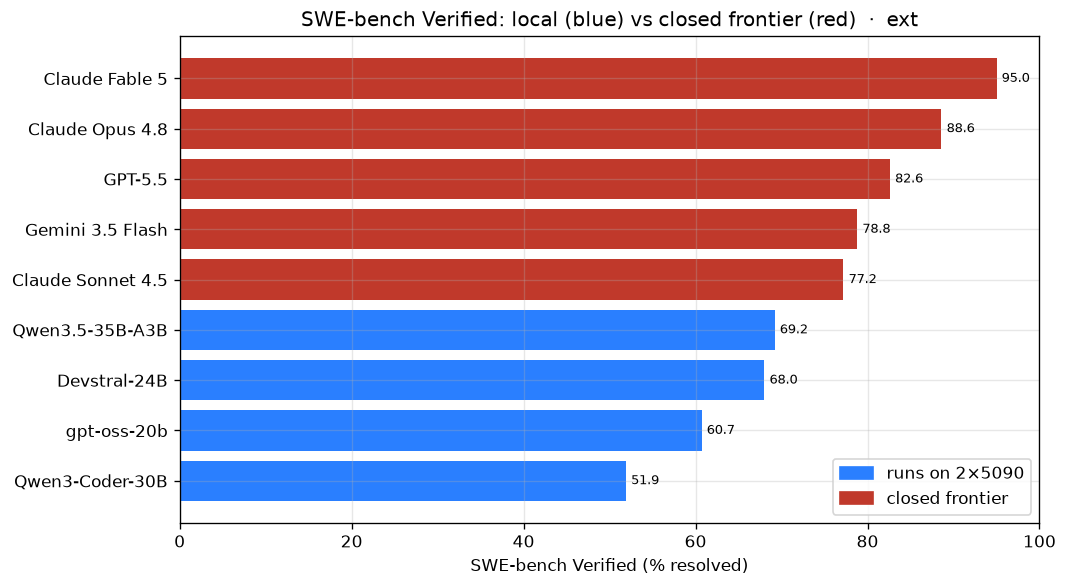

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
items = sorted(SWEBENCH.items(), key=lambda kv: kv[1][0])
names = [k for k, _ in items]
scores = [v[0] for _, v in items]
kinds = [v[2] for _, v in items]
colors = [LOCAL_COLOR if k == "local" else ANCHOR_COLOR for k in kinds]
bars = ax.barh(names, scores, color=colors)
for b, s in zip(bars, scores):
    ax.text(s + 0.6, b.get_y() + b.get_height() / 2, f"{s:.1f}", va="center", fontsize=8)
ax.set_xlabel("SWE-bench Verified (% resolved)")
ax.set_title("SWE-bench Verified: local (blue) vs closed frontier (red)  ·  ext")
ax.set_xlim(0, 100)
from matplotlib.patches import Patch

ax.legend(handles=[Patch(color=LOCAL_COLOR, label="runs on 2×5090"), Patch(color=ANCHOR_COLOR, label="closed frontier")], loc="lower right")
fig.tight_layout()
fig.savefig("fig3_swebench.png", bbox_inches="tight")

## 4. The money plot — speed (measured) × coding skill (SWE-bench)

Our runnable models placed in {decode tok/s we measured} × {SWE-bench}. Dashed
lines mark where the closed frontier sits — the vertical gap is "how far below
frontier coding skill our local options are," the x-axis is what we pay in speed.

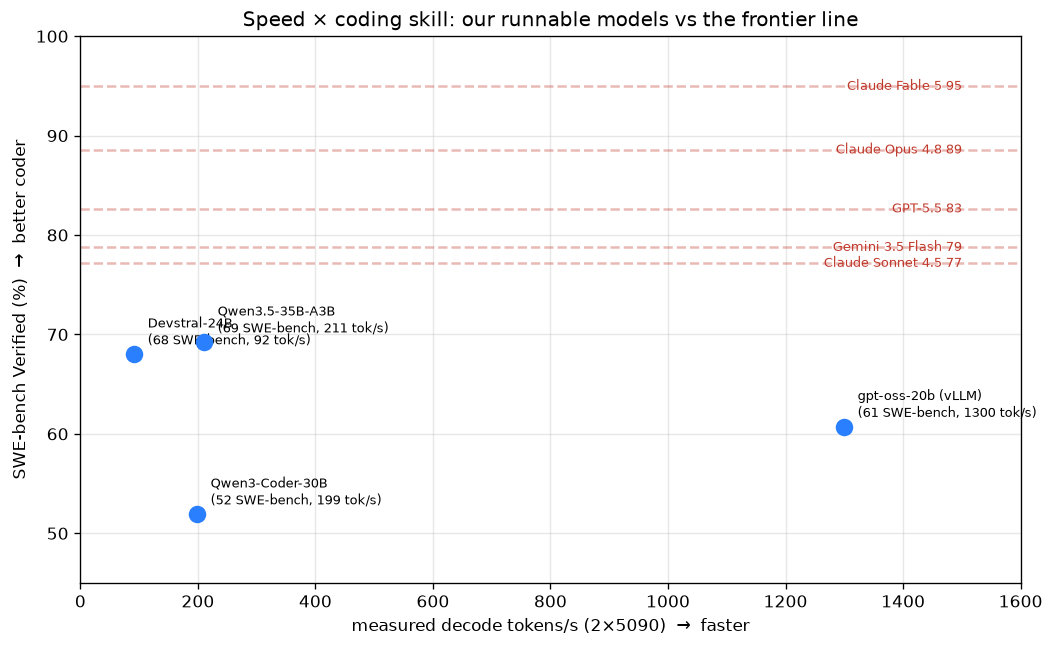

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
pts = {
    "Qwen3-Coder-30B": ("Qwen3-Coder-30B", 199),
    "gpt-oss-20b (vLLM)": ("gpt-oss-20b", 1300),  # ~median measured
    "Devstral-24B": ("Devstral-24B", 92),
    "Qwen3.5-35B-A3B": ("Qwen3.5-35B-A3B", 211),
}
for lbl, (swe_key, tps) in pts.items():
    y = SWEBENCH[swe_key][0]
    ax.scatter(tps, y, s=90, color=LOCAL_COLOR, zorder=3)
    ax.annotate(f"{lbl}\n({y:.0f} SWE-bench, {tps} tok/s)", (tps, y), textcoords="offset points", xytext=(8, 6), fontsize=8)
for name, (s, _, kind) in SWEBENCH.items():
    if kind == "anchor":
        ax.axhline(s, ls="--", color=ANCHOR_COLOR, alpha=0.35)
        ax.text(1500, s, f"{name} {s:.0f}", color=ANCHOR_COLOR, fontsize=7.5, va="center", ha="right")
ax.set_xlabel("measured decode tokens/s (2×5090)  →  faster")
ax.set_ylabel("SWE-bench Verified (%)  →  better coder")
ax.set_title("Speed × coding skill: our runnable models vs the frontier line")
ax.set_xlim(0, 1600)
ax.set_ylim(45, 100)
fig.tight_layout()
fig.savefig("fig4_pareto.png", bbox_inches="tight")

## 5. Reasoning evals (where models report them)

Coding specialists (Qwen3-Coder, Devstral) mostly don't publish GPQA/AIME, so
coverage is sparse — only the reasoning-capable models appear.

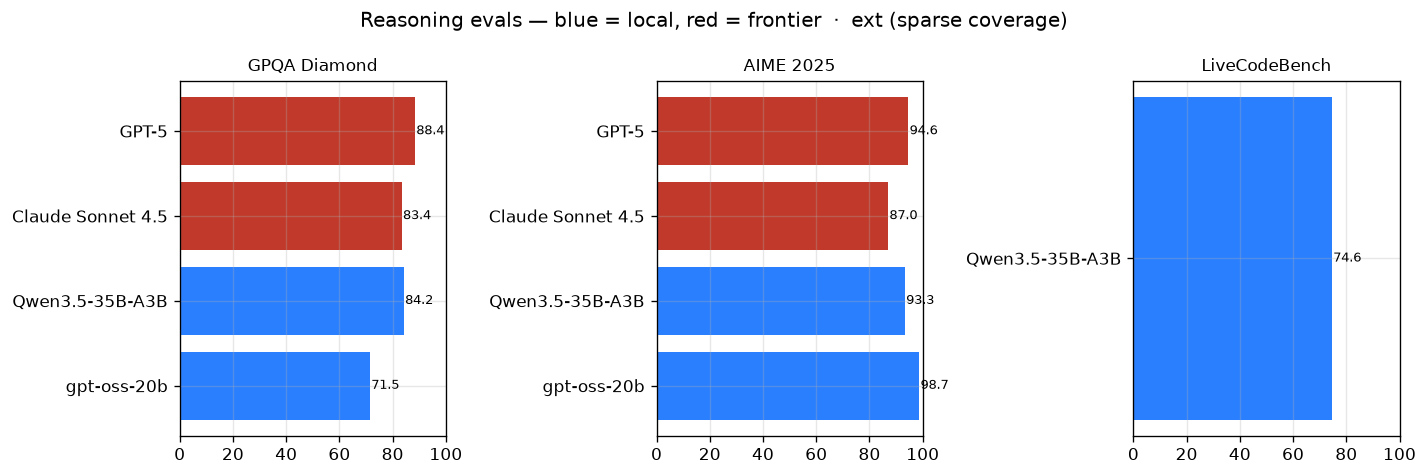

In [7]:
fig, axes = plt.subplots(1, len(REASONING), figsize=(12, 4), sharey=False)
for ax, (metric, d) in zip(axes, REASONING.items()):
    names = list(d.keys())
    vals = list(d.values())
    cols = [LOCAL_COLOR if n in {"gpt-oss-20b", "Qwen3.5-35B-A3B"} else ANCHOR_COLOR for n in names]
    ax.barh(names, vals, color=cols)
    for i, v in enumerate(vals):
        ax.text(v + 0.5, i, f"{v:.1f}", va="center", fontsize=7.5)
    ax.set_title(metric, fontsize=10)
    ax.set_xlim(0, 100)
fig.suptitle("Reasoning evals — blue = local, red = frontier  ·  ext (sparse coverage)")
fig.tight_layout()
fig.savefig("fig5_reasoning.png", bbox_inches="tight")

## Sources

Every eval number above traces to one of these (printed with the run):

In [8]:
for k, v in SOURCES.items():
    print(f"{k:12s} {v}")
print("\nEval provenance: SWE-bench self-reports are scaffold-dependent; vals.ai is")
print("an independent leaderboard (2026-07-17). Numbers are indicative, not exact-comparable.")

qwen3coder   https://huggingface.co/Qwen/Qwen3-Coder-30B-A3B-Instruct
gptoss       https://arxiv.org/abs/2508.10925
qwen35       https://huggingface.co/Qwen/Qwen3.5-35B-A3B
devstral     https://mistral.ai/news/devstral-2-vibe-cli/
valsai_swe   https://www.vals.ai/benchmarks/swebench
gpt5         https://openai.com/index/introducing-gpt-5/
sonnet45     https://www.anthropic.com/news/claude-sonnet-4-5
runs         cluster/docs/inference/runs/  (E1–E5, measured on 2×5090)

Eval provenance: SWE-bench self-reports are scaffold-dependent; vals.ai is
an independent leaderboard (2026-07-17). Numbers are indicative, not exact-comparable.
